# 🤖 LangGraph Examples - 2: A Sequential Graph

**Author:** *José Ignacio Orlando, PhD*

In this second example, we're going to learn how to structure a sequential execution graph in LangGraph, still with no LLMs involved. 

Our goal with this example is to learn how to connect multiple nodes sequentially, to process and update different part of the state, connecting them with edges and seeing how the state if changed step-by-step.

## Step 1 - Define the agent state

In this example, we're going to build a more complex pipeline that demonstrates how multiple nodes can work together sequentially. Our pipeline will generate random numbers, compute their sum, and then calculate their average.

For this sequential workflow, we need to define a state that can hold different types of data as it flows through our pipeline. Unlike the previous example where we only needed a simple message, here we need to track:

1. **numbers**: A list of integers that will be generated by our first node
2. **total**: The sum of all numbers, computed by our second node  
3. **average**: The average value, calculated by our third node

Notice that we're using `total=False` in our `TypedDict` definition. This means that not all fields need to be present in the state at all times - they can be added progressively as our nodes execute. This is perfect for sequential pipelines where each step builds upon the previous one.

In [1]:
# import the TypedDict we need to inherit from, and the List type
from typing import TypedDict, List

# implement the class with total=False so that we don't have all the state all the time
class PipelineState(TypedDict, total=False):
    numbers: List[int] # list of random numbers
    total: int # total sum of the random numbers
    average: float # final average

## Step 2 - Define the nodes

Now we're going to define three different nodes that will work together in sequence. Each node has a specific responsibility and will update the state with its own piece of information.

* **Node 1: `generate_numbers`** - This node creates a list of 5 random integers between 1 and 10. It's our data source node that populates the initial data for our pipeline.
* **Node 2: `compute_sum`** - This node reads the numbers from the state and calculates their total sum. Notice how it uses `state.get("numbers", [])` to safely access the numbers, providing an empty list as a default if the numbers aren't present yet.
* **Node 3: `compute_average`** - This node calculates the average of the numbers. It includes error handling to avoid division by zero if no numbers are present.

Each node follows the same pattern: it receives the current state, performs its computation, and returns a dictionary with the new data to be merged into the state. This is how information flows through our sequential pipeline.

In [2]:
# import randint to generate random integers
from random import randint

# node for generating random numbers
def generate_numbers(state: PipelineState) -> PipelineState:
    """Generate a list of five random integers between 1 and 10."""
    # generate 5 random integers between 1 and 10
    numbers = [randint(1, 10) for _ in range(5)]
    return {"numbers": numbers}

def compute_sum(state: PipelineState) -> PipelineState:
    """Compute the sum of all numbers."""
    # retrieve the numbers from the state, safely (if they are not there, will get an empty list)
    numbers = state.get("numbers", [])
    # sum all numbers in the list
    total = sum(numbers)
    return {"total": total}

def compute_average(state: PipelineState) -> PipelineState:
    """Compute the average value."""
    # retrieve the numbers safely again, to better handle what to do if we don't have it
    numbers = state.get("numbers", [])
    # if numbers are not there, return average 0
    if not numbers:
        return {"average": 0.0}
    # else, calculate average as total divided by len
    else:
        avg = state["total"] / len(numbers)
        return {"average": avg}

## Step 3 - Define the execution graph

Now comes the exciting part - connecting our nodes in a sequential workflow! Unlike the previous example where we had implicit START and END connections, here we're going to explicitly define the edges between our nodes to create a clear sequential flow.

The workflow we're building follows this sequence:
1. **START** → `generate_numbers` (generate random numbers)
2. `generate_numbers` → `compute_sum` (calculate the sum)  
3. `compute_sum` → `compute_average` (calculate the average)
4. `compute_average` → **END** (finish the pipeline)

We use `add_edge()` to explicitly connect each node to the next one in the sequence. This creates a linear pipeline where each node depends on the output of the previous node. The state flows through each node, getting enriched with new information at each step.

Notice how we import both `START` and `END` from `langgraph.graph` - these are special constants that represent the beginning and end of our execution graph.

In [3]:
# import StateGraph and the START and END nodes 
from langgraph.graph import StateGraph, START, END

# initialize the StateGraph with the PipelineState we defined before
workflow = StateGraph(PipelineState)

# add the nodes
workflow.add_node("generate_numbers", generate_numbers)
workflow.add_node("compute_sum", compute_sum)
workflow.add_node("compute_average", compute_average)

# add the edges in the right order
workflow.add_edge(START, "generate_numbers")
workflow.add_edge("generate_numbers", "compute_sum")
workflow.add_edge("compute_sum", "compute_average")
workflow.add_edge("compute_average", END)

# compile the workflow
app = workflow.compile()

Let's visualize our sequential pipeline! This will help us see how the nodes are connected and understand the flow of data through our graph.

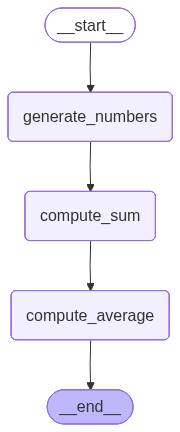

In [4]:
from IPython.display import Image, display
# retrieve the graph, draw the mermaing code, model that as an image, and display it
display(Image(app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

## Step 4 - Execute!

Time to run our sequential pipeline. In this example, we're going to use two different methods to execute our graph:

1. **Streaming execution** - This shows us the state updates as they happen, node by node. We can see exactly what each node produces and how the state evolves through the pipeline.
2. **Final execution** - This gives us the complete final state after all nodes have executed.

The streaming approach is particularly useful for debugging and understanding how data flows through complex pipelines. You'll see each node emit its contribution to the state, building up the final result step by step.

Notice how the state grows progressively: first we get the numbers, then the total is added, and finally the average is calculated.

In [5]:
from pprint import pprint

# initialize an empty state to start our pipeline
initial_state = {}

# demonstrate streaming execution to see state updates in real-time
print("== Streaming state updates ==")
for update in app.stream(initial_state):
    for node, delta in update.items():
        print(f"\n[{node}] emitted:")
        pprint(delta)

# demonstrate final execution to get the complete result
print("\n== Final state ==")
final_state = app.invoke(initial_state)
pprint(final_state)

== Streaming state updates ==

[generate_numbers] emitted:
{'numbers': [4, 1, 4, 1, 7]}

[compute_sum] emitted:
{'total': 17}

[compute_average] emitted:
{'average': 3.4}

== Final state ==
{'average': 4.2, 'numbers': [1, 9, 4, 3, 4], 'total': 21}


Perfect! You've now seen how to build a sequential pipeline in LangGraph. This example demonstrates several key concepts:

- **State management**: How to design a state that grows progressively through the pipeline
- **Sequential connections**: How to explicitly connect nodes in a specific order using edges
- **Data flow**: How information flows from one node to the next, with each node building upon the previous one
- **Streaming execution**: How to observe the state changes as they happen in real-time

This sequential pattern is the foundation for more complex workflows. In the next examples, we'll explore conditional branching, loops, and eventually integrate LLMs to create truly intelligent agents!